In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# Load cleaned YC data
df = pd.read_csv("../data/cleaned/yc_companies_clean.csv")
df.head()

,company,slug,batch,status,company_size,locations,description,long_description,website,as_of_date,batch_year,batch_season,company_size_num,company_size_bucket
0,CircuitHub,circuithub,Winter 2012,Active,58.0,"London, England, United Kingdom",On-Demand Electronics Manufacturing,CircuitHub offers on-demand electronics manufa...,https://circuithub.com,2026-02-08,2012.0,W,58.0,scaling
1,iCracked,icracked,Winter 2012,Acquired,51.0,"Redwood City, CA, USA",On-demand smartphone repair in 3 countries and...,Founded in 2010 and located in the heart of Si...,http://icracked.com,2026-02-08,2012.0,W,51.0,scaling
2,42Floors,42floors,Winter 2012,Acquired,60.0,"San Francisco, CA, USA; Remote",We make it easy to search for office space.,*Acquired by Knotel in 2018\r\n\r\n42Floors wa...,http://42floors.com,2026-02-08,2012.0,W,60.0,scaling
3,PlanGrid,plangrid,Winter 2012,Acquired,355.0,"San Francisco, CA, USA",Mobile applications for the construction indus...,PlanGrid is the leader in construction product...,http://plangrid.com,2026-02-08,2012.0,W,355.0,large
4,WireOver,wireover,Winter 2012,Inactive,2.0,"Cambridge, MA, USA",Really secure file sending for big files.,WireOver is a desktop application that leverag...,http://wireover.com,2026-02-08,2012.0,W,2.0,small


In [2]:
# Drop rows without batch year
df = df.dropna(subset=["batch_year"]).copy()


# Define AI era (ChatGPT inflection ~2022)
df["era"] = df["batch_year"].apply(lambda y: "pre_ai" if y < 2022 else "post_ai")


# Sanity check
df[["batch_year", "era"]].drop_duplicates().sort_values("batch_year")

,batch_year,era
361,2005.0,pre_ai
343,2006.0,pre_ai
312,2007.0,pre_ai
269,2008.0,pre_ai
227,2009.0,pre_ai
165,2010.0,pre_ai
61,2011.0,pre_ai
0,2012.0,pre_ai
454,2013.0,pre_ai
552,2014.0,pre_ai


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer


texts = df["description"].fillna("").str.lower()


vectorizer = TfidfVectorizer(
stop_words="english",
max_df=0.8,
min_df=10,
ngram_range=(1, 2)
)


X = vectorizer.fit_transform(texts)

In [4]:
from sklearn.cluster import KMeans


N_CLUSTERS = 10


kmeans = KMeans(
n_clusters=N_CLUSTERS,
random_state=42,
n_init=10
)


df["cluster"] = kmeans.fit_predict(X)

In [5]:
cluster_labels = {
0: "B2B SaaS / Sales Ops",
1: "Healthcare / Compliance",
2: "Marketplaces / SMB Tools",
3: "Fintech / Wealth",
4: "AI Platforms / Infra",
5: "AI Agents / Voice",
6: "Data / Models / Performance",
7: "AI Ops / Automation",
8: "Data / APIs / Analytics",
9: "Media / Video / Creators"
}


df["cluster_label"] = df["cluster"].map(cluster_labels)

In [6]:
cluster_era_counts = (
df.groupby(["era", "cluster_label"])
.size()
.reset_index(name="count")
)


cluster_era_counts

,era,cluster_label,count
0,post_ai,AI Agents / Voice,614
1,post_ai,AI Ops / Automation,147
2,post_ai,AI Platforms / Infra,164
3,post_ai,B2B SaaS / Sales Ops,77
4,post_ai,Data / APIs / Analytics,112
5,post_ai,Data / Models / Performance,28
6,post_ai,Fintech / Wealth,46
7,post_ai,Healthcare / Compliance,101
8,post_ai,Marketplaces / SMB Tools,1170
9,post_ai,Media / Video / Creators,27


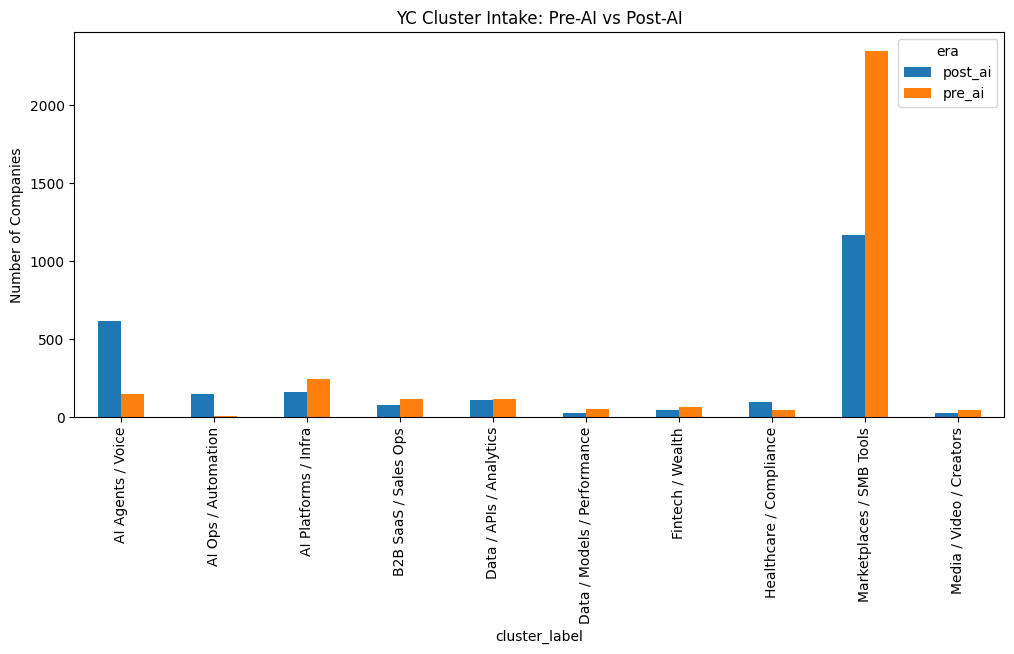

In [7]:
pivot = (
cluster_era_counts
.pivot(index="cluster_label", columns="era", values="count")
.fillna(0)
)


pivot.plot(kind="bar", figsize=(12,5))
plt.title("YC Cluster Intake: Pre-AI vs Post-AI")
plt.ylabel("Number of Companies")
plt.show()

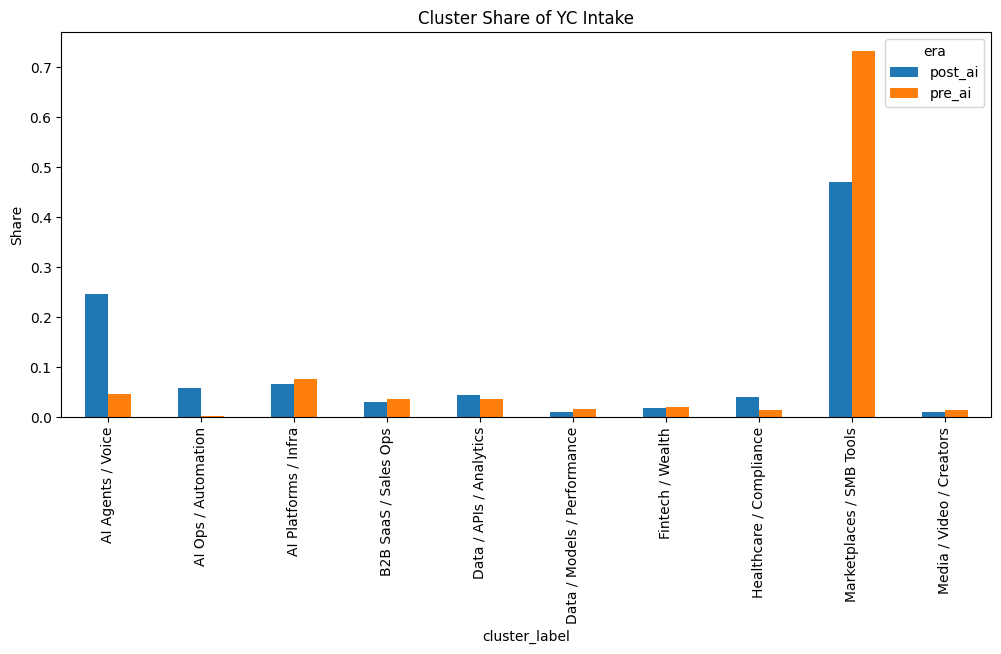

In [8]:
share = pivot.div(pivot.sum(axis=0), axis=1)


share.plot(kind="bar", figsize=(12,5))
plt.title("Cluster Share of YC Intake")
plt.ylabel("Share")
plt.show()

In [10]:
bucket_era = (
df.groupby(["era", "cluster_label", "company_size_bucket"])
.size()
.reset_index(name="count")
)


success = bucket_era[
bucket_era["company_size_bucket"].isin(["scaling", "large"])
]


success_rate = (
success.groupby(["era", "cluster_label"])["count"].sum()
/
df.groupby(["era", "cluster_label"]).size()
).reset_index(name="success_rate")


success_rate

,era,cluster_label,success_rate
0,post_ai,AI Agents / Voice,0.029316
1,post_ai,AI Ops / Automation,0.013605
2,post_ai,AI Platforms / Infra,0.067073
3,post_ai,B2B SaaS / Sales Ops,0.051948
4,post_ai,Data / APIs / Analytics,0.035714
5,post_ai,Data / Models / Performance,0.071429
6,post_ai,Fintech / Wealth,0.021739
7,post_ai,Healthcare / Compliance,0.019802
8,post_ai,Marketplaces / SMB Tools,0.041026
9,post_ai,Media / Video / Creators,NaN


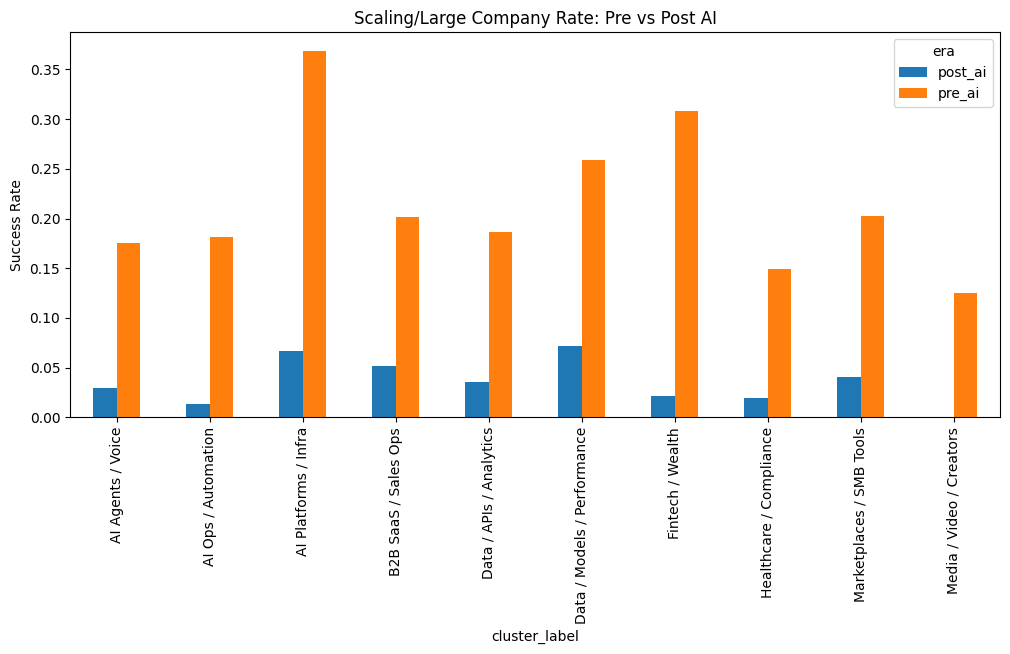

In [11]:
success_pivot = success_rate.pivot(
index="cluster_label",
columns="era",
values="success_rate"
)


success_pivot.plot(kind="bar", figsize=(12,5))
plt.title("Scaling/Large Company Rate: Pre vs Post AI")
plt.ylabel("Success Rate")
plt.show()

## Summary I
Initially, I wanted to see what startups could have won in this AI race. But given that the data for the AI era is still young. The task is inefficient.

In [12]:
# Define what "now" means (last N years)
CURRENT_START_YEAR = 2022

recent_df = df[df["batch_year"] >= CURRENT_START_YEAR].copy()

recent_df["batch_year"].value_counts().sort_index()


batch_year
2022.0    633
2023.0    495
2024.0    593
2025.0    631
2026.0    134
Name: count, dtype: int64

In [13]:
current_cluster_counts = (
    recent_df["cluster_label"]
    .value_counts()
    .sort_values(ascending=False)
)

current_cluster_counts


cluster_label
Marketplaces / SMB Tools       1170
AI Agents / Voice               614
AI Platforms / Infra            164
AI Ops / Automation             147
Data / APIs / Analytics         112
Healthcare / Compliance         101
B2B SaaS / Sales Ops             77
Fintech / Wealth                 46
Data / Models / Performance      28
Media / Video / Creators         27
Name: count, dtype: int64

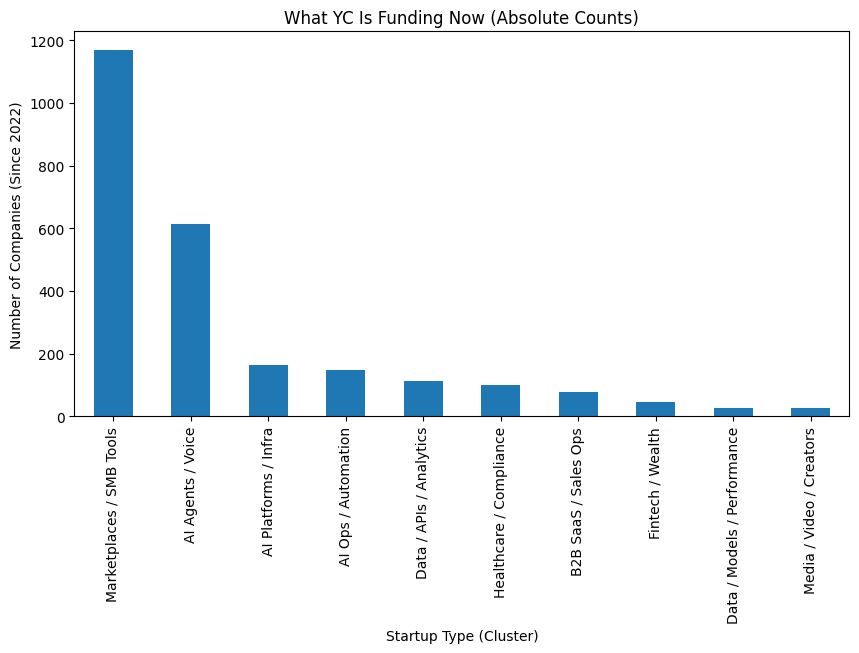

In [14]:
current_cluster_counts.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("What YC Is Funding Now (Absolute Counts)")
plt.ylabel("Number of Companies (Since 2022)")
plt.xlabel("Startup Type (Cluster)")
plt.show()


In [15]:
current_cluster_share = (
    current_cluster_counts
    / current_cluster_counts.sum()
)

current_cluster_share


cluster_label
Marketplaces / SMB Tools       0.470636
AI Agents / Voice              0.246983
AI Platforms / Infra           0.065969
AI Ops / Automation            0.059131
Data / APIs / Analytics        0.045052
Healthcare / Compliance        0.040628
B2B SaaS / Sales Ops           0.030973
Fintech / Wealth               0.018504
Data / Models / Performance    0.011263
Media / Video / Creators       0.010861
Name: count, dtype: float64

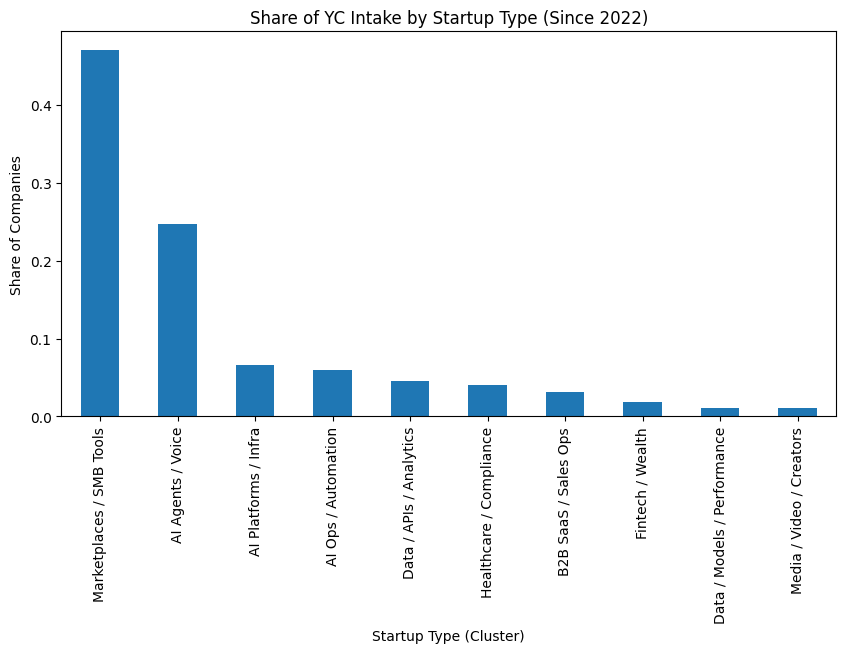

In [16]:
current_cluster_share.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Share of YC Intake by Startup Type (Since 2022)")
plt.ylabel("Share of Companies")
plt.xlabel("Startup Type (Cluster)")
plt.show()


In [17]:
current_year_cluster = (
    recent_df
    .groupby(["batch_year", "cluster_label"])
    .size()
    .reset_index(name="count")
)

current_year_cluster.head()


,batch_year,cluster_label,count
0,2022.0,AI Agents / Voice,70
1,2022.0,AI Ops / Automation,14
2,2022.0,AI Platforms / Infra,54
3,2022.0,B2B SaaS / Sales Ops,16
4,2022.0,Data / APIs / Analytics,30


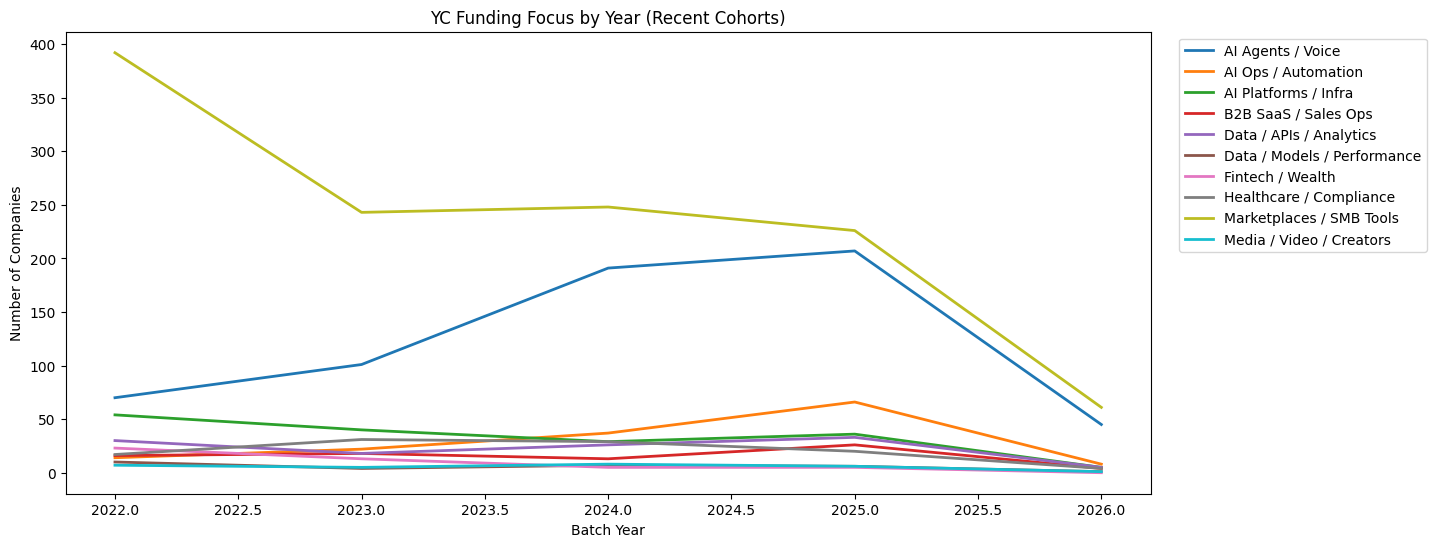

In [18]:
pivot_now = (
    current_year_cluster
    .pivot(index="batch_year", columns="cluster_label", values="count")
    .fillna(0)
)

pivot_now.plot(
    figsize=(14,6),
    linewidth=2
)

plt.title("YC Funding Focus by Year (Recent Cohorts)")
plt.xlabel("Batch Year")
plt.ylabel("Number of Companies")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()


In [19]:
year_cluster_counts = (
    df.groupby(["batch_year", "cluster_label"])
      .size()
      .reset_index(name="count")
)


In [20]:
pivot_all = (
    year_cluster_counts
    .pivot(index="batch_year", columns="cluster_label", values="count")
    .fillna(0)
)


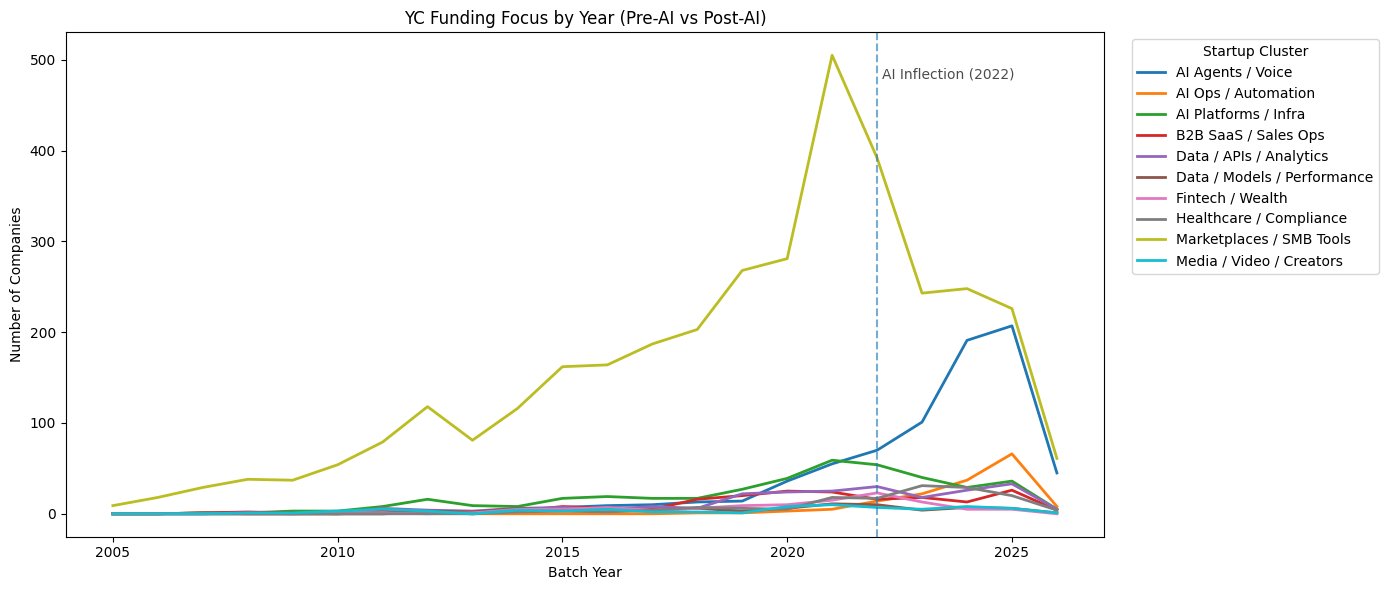

In [21]:
plt.figure(figsize=(14,6))

pivot_all.plot(
    ax=plt.gca(),
    linewidth=2
)

# Mark AI inflection
plt.axvline(2022, linestyle="--", alpha=0.6)
plt.text(2022.1, pivot_all.max().max()*0.95, "AI Inflection (2022)", alpha=0.7)

plt.title("YC Funding Focus by Year (Pre-AI vs Post-AI)")
plt.xlabel("Batch Year")
plt.ylabel("Number of Companies")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Startup Cluster"
)

plt.tight_layout()
plt.show()


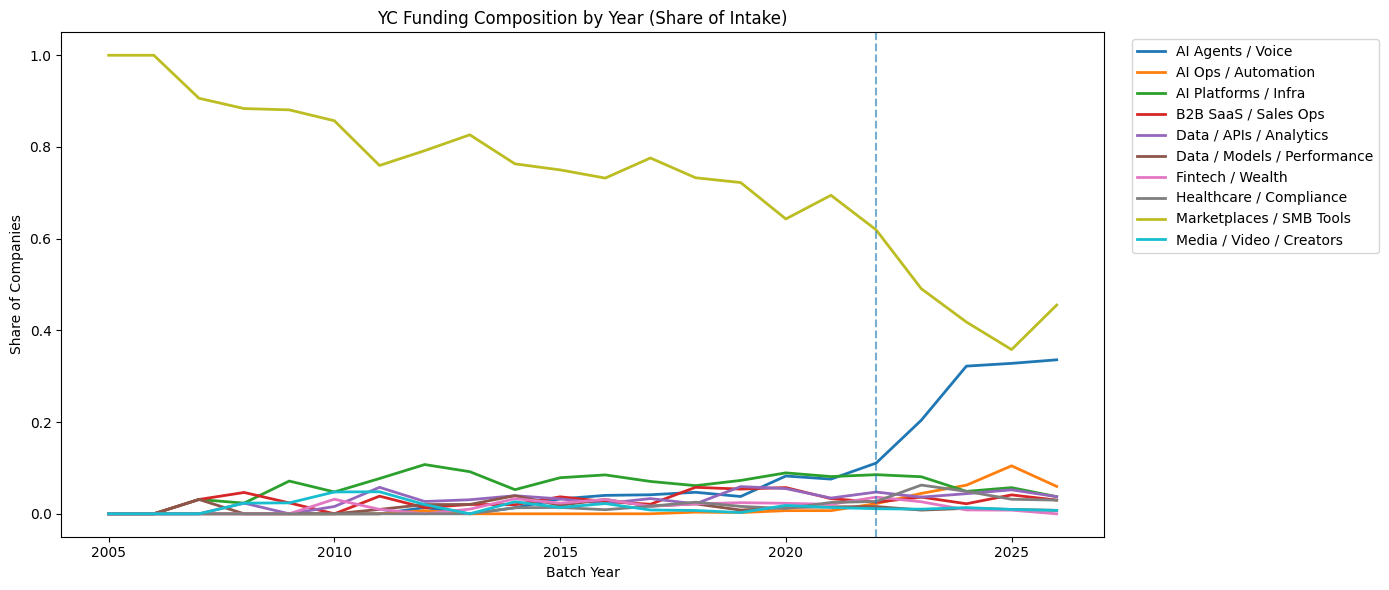

In [22]:
share_all = pivot_all.div(pivot_all.sum(axis=1), axis=0)

share_all.plot(figsize=(14,6), linewidth=2)
plt.axvline(2022, linestyle="--", alpha=0.6)
plt.title("YC Funding Composition by Year (Share of Intake)")
plt.ylabel("Share of Companies")
plt.xlabel("Batch Year")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Summary II

- YC becomes more selective with a smaller batch.
- Marketplaces and SMB tools see a decline, while AI Agent/AI voice see a huge increase.
- There is a spike for AI Ops and automation
- AI platform/Infra stays steady throughout the years

AI agents and AI voices are dominating the race right now. It shows that software is not just a tool but also a worker.